In [2]:
%pip install google-adk -q

Note: you may need to restart the kernel to use updated packages.


In [1]:
print("Hello, Google ADK!")

Hello, Google ADK!


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()
try:
    GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
    if GOOGLE_API_KEY:
        print("✅ Google API key loaded successfully.")
    else:
        print("⚠️ Google API key not found. Please set it in the .env file.")
except Exception as e:
    print(f"🔑 Error loading Google API key: {e}")

✅ Google API key loaded successfully.


In [4]:
from typing import Any, Dict

from google.adk.agents import Agent, LlmAgent
from google.adk.apps.app import App, EventsCompactionConfig
from google.adk.models.google_llm import Gemini
from google.adk.sessions import DatabaseSessionService
from google.adk.sessions import InMemorySessionService
from google.adk.runners import Runner
from google.adk.tools.tool_context import ToolContext
from google.genai import types

print("✅ ADK components imported successfully.")

✅ ADK components imported successfully.


In [5]:
system_prompt = """
You are GuardianAI — a crisis response coordinator.

Your role is to:
- Analyze the user's message.
- Decide which specialized agent should handle the situation:
  - FireAgent
  - MedicalAgent
  - ThreatAgent
  - EmotionalSupportAgent
  
- Delegate the conversation appropriately.
- Provide clear, concise instructions to the user if needed.
- Always ensure the user's safety and well-being.
- If user suggests self-harm or harm to others or some life-threatening situation, flag the severity as CRITICAL and escalate to emergency services and guide them.

Routing Rules:
- Fire, smoke, flames, gas → FireAgent
- Medical emergency, unconscious, chest pain → MedicalAgent
- Threat, stalking, break-in → ThreatAgent
- Panic, anxiety, emotional distress → EmotionalSupportAgent
- If unclear → respond calmly yourself.

Always prioritize safety.
Never ignore life-threatening signals.
Maintain a calm, non- judegmental structured tone.
"""


In [6]:
import json

CRISIS_FILE = "guardian_resources.json"

resources = {
    "emotional_support": {
        "helpline": "India Mental Health Support: 1800-599-0019",
        "steps": [
            "Take 3 slow deep breaths.",
            "Name 5 things you can see near you.",
            "You're not alone — help is available."
        ]
    },
    "medical_emergency": {
        "helpline": "Ambulance: 102",
        "steps": [
            "Check if the person is conscious.",
            "Call emergency services immediately.",
            "Stay calm and monitor their breathing."
        ]
    },
    "safety_threat": {
        "helpline": "Police Emergency Number: 112",
        "steps": [
            "Move to a safe and visible public place if possible.",
            "Avoid confrontation.",
            "Contact emergency services immediately."
        ]
    },
    "fire_hazard": {
        "helpline": "Fire & Rescue: 101",
        "steps": [
            "Evacuate calmly and quickly.",
            "Avoid elevators.",
            "Call emergency services immediately."
        ]
    }
}

with open(CRISIS_FILE, "w") as f:
    json.dump(resources, f, indent=4)

print("📁 Crisis resources stored successfully.")


📁 Crisis resources stored successfully.


In [7]:
def get_emergency_numbers(country):

    EMERGENCY_NUMBERS = {
        "india": {"police": "112", "medical": "102", "fire": "101"},
        "usa": {"general": "911"},
        "uk": {"general": "999"},
        "australia": {"general": "000"},
    }

    return EMERGENCY_NUMBERS.get(country.lower(), {"general": "112"})

In [8]:
def load_crisis_resources():

    with open("guardian_resources.json") as f:
        return json.load(f)

In [9]:
# New code cell 6

# Step 6: Define function the agent will call
def fetch_support(category: str) -> dict:
    """Retrieve guidance based on crisis type."""
    with open("guardian_resources.json", "r") as f:
        data = json.load(f)
    return data.get(category.lower(), {"error": "Unknown crisis type"})

from google.adk.tools import FunctionTool

crisis_tool = FunctionTool(fetch_support)
print("🛠️ FunctionTool registered successfully!")


🛠️ FunctionTool registered successfully!


In [10]:
# Code cell 7
from google.adk import Agent

guardian_agent = LlmAgent(
    name="GuardianAI",
    model="gemini-2.5-pro",
    description="A crisis intervention agent for helping people in emergency situations.",
    instruction= system_prompt
)

print("🧠 GuardianAI created successfully!")


🧠 GuardianAI created successfully!


In [11]:
# Code cell 8
app = App(
    name="GuardianAI_App",
    root_agent=guardian_agent
)

print("📦 App created successfully!")


from google.adk.sessions import InMemorySessionService

session_service = InMemorySessionService()

runner = Runner(
    app=app,                  
    session_service=session_service
)

print("🚀 Runner initialized!")


📦 App created successfully!
🚀 Runner initialized!


In [12]:
# Define session identifiers
USER_ID = "guardian_user"
SESSION_ID = "guardian_session"

# Create session once
await session_service.create_session(
    user_id = USER_ID,
    session_id = SESSION_ID,
    app_name=app.name
)

print("✅ Session initialized properly.")

✅ Session initialized properly.


In [13]:
# New Code cell 9
from google.genai.types import GenerateContentConfig

guardian_agent.generate_content_config = GenerateContentConfig(
    temperature=0.3,
    max_output_tokens=500,
)
print("⚙️ Text generation config applied.")


⚙️ Text generation config applied.


In [14]:
# New new Cell 11 — Fire Crisis Response Agent, old code cell 24 - NEW Code cell 16

from google.adk.agents import LlmAgent

fire_agent = LlmAgent(
    name="FireAgent",
    model="gemini-2.5-pro",
    instruction="""
You are FireAgent — specialized in fire-related emergencies.
Your responses MUST:

- Tell the user to evacuate if there is active fire/smoke.
- Give 4–6 short steps that are immediately actionable.
- Stay calm, clear, and urgent.
- Avoid suggesting legal/medical replacements.
"""
)

print("🔥 FireAgent ready!")


🔥 FireAgent ready!


In [15]:
# new new code cell 12
from google.adk.agents import LlmAgent
MedicalAgent = LlmAgent(
    name="MedicalAgent",
    model="gemini-2.5-pro",
    instruction="""
You are the Medical Response Agent.

Mode: CRITICAL + DECISIVE + CALM.

Rules:
- Use VERY SHORT clear bullet points.
- Do NOT diagnose conditions.
- Do NOT give medications.
- Prioritize safety and professional help.

If CRITICAL:
- Move user toward immediate actions.
- Encourage calling emergency services.
- Keep language simple and supportive.

If NOT critical:
- Give reassurance and basic safety steps.

Tone:
- Calm
- Direct
- Supportive
"""
)

print("❤️ Medical Assistance Agent Ready.")


❤️ Medical Assistance Agent Ready.


In [16]:
# Cell 28 — Threat / Personal Safety Agent, new cell 18 - new new code cell 13

ThreatAgent = LlmAgent(
    name="ThreatAgent",
    model="gemini-2.5-pro",
    instruction="""
You are the Personal Safety Agent.

Purpose:
- Assist users facing stalking, harassment, physical threats, or unsafe environments.

Tone:
- Calm, protective, confident, non-judgmental.

Rules:
- First priority: Get user to safety.
- Encourage moving to a public, well-lit area.
- Never encourage confrontation.
- Do NOT give legal advice — recommend contacting authorities.

Response Style:
- Short steps.
- Clear reasoning.
- Supportive check-ins ("Are you safe?", "Can you move somewhere with people?")
"""
)
print("🛡️ Threat Safety Agent Ready.")

🛡️ Threat Safety Agent Ready.


In [17]:
# Cell 29 — Emotional Support Agent, new cell 19, new new code cell 14

EmotionalAgent = LlmAgent(
    name="EmotionalSupportAgent",
    model="gemini-2.5-pro",
    instruction="""
You are the Emotional Support Agent.

Purpose:
- Help users coping with emotional distress, panic, fear, shock, or overwhelming feelings.

Tone:
- Empathetic
- Validating
- Gentle

Rules:
- Avoid medical diagnoses.
- Encourage grounding exercises (breathing, orientation).
- Offer coping steps and reassurance.
- Validate feelings (“It makes sense you feel overwhelmed.”)

Structure:
1. Acknowledge feelings
2. Grounding step
3. Calm supportive follow-up
4. Ask permission before continuing further
"""
)
print("💙 Emotional Support Agent Ready.")


💙 Emotional Support Agent Ready.


In [18]:
# Create separate apps for each agent

fire_app = App(name="Fire_App", root_agent=fire_agent)
medical_app = App(name="Medical_App", root_agent=MedicalAgent)
threat_app = App(name="Threat_App", root_agent=ThreatAgent)
emotional_app = App(name="Emotional_App", root_agent=EmotionalAgent)
guardian_app = App(name="Guardian_App", root_agent=guardian_agent)

# Create runners
fire_runner = Runner(app=fire_app, session_service=session_service)
medical_runner = Runner(app=medical_app, session_service=session_service)
threat_runner = Runner(app=threat_app, session_service=session_service)
emotional_runner = Runner(app=emotional_app, session_service=session_service)
guardian_runner = Runner(app=guardian_app, session_service=session_service)

print("✅ Multi-agent runners ready.")

✅ Multi-agent runners ready.


In [19]:
# Create session for all runners

await session_service.create_session(
    user_id=USER_ID,
    session_id=SESSION_ID,
    app_name="Fire_App"
)

await session_service.create_session(
    user_id=USER_ID,
    session_id=SESSION_ID,
    app_name="Medical_App"
)

await session_service.create_session(
    user_id=USER_ID,
    session_id=SESSION_ID,
    app_name="Threat_App"
)

await session_service.create_session(
    user_id=USER_ID,
    session_id=SESSION_ID,
    app_name="Emotional_App"
)

await session_service.create_session(
    user_id=USER_ID,
    session_id=SESSION_ID,
    app_name="Guardian_App"
)

print("✅ Sessions initialized for all agents.")

✅ Sessions initialized for all agents.


In [20]:
import time

conversation_log = []

def log_interaction(user_message, severity, category, agent_name, response_text):

    entry = {
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "user_message": user_message,
        "severity": severity,
        "category": category,
        "agent": agent_name,
        "response_preview": response_text[:150]
    }

    conversation_log.append(entry)

In [22]:
%pip install pandas -q
%pip install matplotlib -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_severity_timeline():

    if not conversation_log:
        print("⚠️ No conversation history yet.")
        return

    df = pd.DataFrame(conversation_log)

    severity_scale = {
        "LOW":1,
        "MODERATE":2,
        "CRITICAL":3
    }

    df["severity_score"] = df["severity"].map(severity_scale)

    plt.figure(figsize=(8,4))

    plt.plot(df["severity_score"], marker="o")

    plt.title("Crisis Severity Escalation")
    plt.xlabel("Interaction Step")
    plt.ylabel("Severity Level")

    plt.yticks([1,2,3], ["LOW","MODERATE","CRITICAL"])

    plt.grid(True)
    plt.show()

In [25]:
async def generate_summary():

    if not conversation_log:
        return "No interaction history."

    prompt = f"""
You are GuardianAI summarizing a crisis interaction.

Here is the conversation log:

{conversation_log}

Write a concise crisis summary including:
- crisis type
- severity progression
- agents involved
- recommended next actions
"""

    summary = ""

    async for event in guardian_runner.run_async(
        new_message=Content(role="user", parts=[Part(text=prompt)]),
        user_id=USER_ID,
        session_id=SESSION_ID
    ):
        if hasattr(event, "content") and event.content:
            for part in event.content.parts:
                if part.text:
                    summary += part.text

    return summary

In [26]:
# from google.genai.types import Content, Part

# def detect_category(message: str) -> str:
#     msg = message.lower()

#     if any(x in msg for x in ["fire", "smoke", "burning", "flames", "gas leak"]):
#         return "fire"
#     if any(x in msg for x in ["bleeding", "collapsed", "can't breathe", "chest pain", "unconscious", "overdose"]):
#         return "medical"
#     if any(x in msg for x in ["following me", "stalking", "threatening", "unsafe", "break in"]):
#         return "threat"
#     if any(x in msg for x in ["panicking", "anxiety", "scared", "crying", "overwhelmed", "shaking", "anxious"]):
#         return "emotional"

#     return "unknown"


# def compute_severity(message: str, category: str) -> str:
#     msg = message.lower()

#     critical_keywords = [
#         "unconscious", "not breathing", "bleeding heavily",
#         "trapped", "locked inside", "suicide", "overdose", "poison"
#     ]

#     if category == "fire":
#         return "CRITICAL"

#     if any(word in msg for word in critical_keywords):
#         return "CRITICAL"

#     if category in ["medical", "threat"]:
#         return "MODERATE"

#     if category == "emotional":
#         return "LOW"

#     return "LOW"

# def explain_decision(message: str, category: str):

#     if category == "fire":
#         return "Fire or smoke related keywords detected."

#     if category == "medical":
#         return "Medical emergency related keywords detected."

#     if category == "threat":
#         return "Safety threat or danger keywords detected."

#     if category == "emotional":
#         return "Emotional distress indicators detected."

#     return "No specific crisis keywords detected — routed to GuardianAI."

# agent_map = {
#     "fire": fire_agent,
#     "medical": MedicalAgent,
#     "threat": ThreatAgent,
#     "emotional": EmotionalAgent,
# }

# async def handle_message(message, forced_agent=None):

#     # -----------------------------
#     # Load crisis resources
#     # -----------------------------
#     resources = load_crisis_resources()

#     # -----------------------------
#     # Determine category
#     # -----------------------------
#     if forced_agent:
#         category = forced_agent
#     else:
#         category = detect_category(message)

#     severity = compute_severity(message, category)
#     reason = explain_decision(message, category)

#     runner_to_use = agent_map.get(category, guardian_runner)

#     agent_name = category.capitalize() + "Agent" if category in agent_map else "GuardianAI"

#     # -----------------------------
#     # Ensure ADK session exists
#     # -----------------------------
#     session_service = runner_to_use.session_service

#     session = await session_service.get_session(
#         user_id=USER_ID,
#         session_id=SESSION_ID,
#         app_name=runner_to_use.app.name
#     )

#     if session is None:
#         await session_service.create_session(
#             user_id=USER_ID,
#             session_id=SESSION_ID,
#             app_name=runner_to_use.app.name
#         )

#     # -----------------------------
#     # Run agent
#     # -----------------------------
#     response_text = ""

#     async for event in runner_to_use.run_async(
#         new_message=Content(role="user", parts=[Part(text=message)]),
#         user_id=USER_ID,
#         session_id=SESSION_ID
#     ):
#         if hasattr(event, "content") and event.content:
#             for part in event.content.parts:
#                 if part.text:
#                     response_text += part.text

#     # -----------------------------
#     # Attach emergency guidance
#     # -----------------------------
#     help_text = ""

#     if category == "fire":
#         help_info = resources["fire_hazard"]

#     elif category == "medical":
#         help_info = resources["medical_emergency"]

#     elif category == "threat":
#         help_info = resources["safety_threat"]

#     elif category == "emotional":
#         help_info = resources["emotional_support"]

#     else:
#         help_info = None

#     if help_info:
#         steps = "\n".join([f"- {s}" for s in help_info["steps"]])

#         help_text = f"""
# Emergency Helpline: {help_info['helpline']}

# Recommended Steps:
# {steps}
# """

#     # -----------------------------
#     # Log interaction
#     # -----------------------------
#     log_interaction(
#         message,
#         severity,
#         category,
#         agent_name,
#         response_text
#     )

#     # -----------------------------
#     # Final response
#     # -----------------------------
#     return {
#     "severity": severity,
#     "category": category,
#     "agent": agent_name,
#     "reason": reason,
#     "response": response_text
#     }

from google.genai.types import Content, Part

# -----------------------------
# Category Detection
# -----------------------------

def detect_category(message: str) -> str:

    msg = message.lower()

    if any(x in msg for x in ["fire", "smoke", "burning", "flames", "gas leak"]):
        return "fire"

    if any(x in msg for x in ["bleeding", "collapsed", "can't breathe", "chest pain", "unconscious", "overdose"]):
        return "medical"

    if any(x in msg for x in ["following me", "stalking", "threatening", "unsafe", "break in"]):
        return "threat"

    if any(x in msg for x in ["panicking", "anxiety", "scared", "crying", "overwhelmed", "shaking", "anxious"]):
        return "emotional"

    return "unknown"


# -----------------------------
# Severity
# -----------------------------

def compute_severity(message: str, category: str):

    msg = message.lower()

    critical_keywords = [
        "unconscious","not breathing","bleeding heavily",
        "trapped","locked inside","suicide","overdose","poison"
    ]

    if category == "fire":
        return "CRITICAL"

    if any(word in msg for word in critical_keywords):
        return "CRITICAL"

    if category in ["medical","threat"]:
        return "MODERATE"

    if category == "emotional":
        return "LOW"

    return "LOW"


# -----------------------------
# Explainability
# -----------------------------

def explain_decision(message: str, category: str):

    if category == "fire":
        return "Fire or smoke related keywords detected."

    if category == "medical":
        return "Medical emergency related keywords detected."

    if category == "threat":
        return "Safety threat keywords detected."

    if category == "emotional":
        return "Emotional distress indicators detected."

    return "No crisis keywords detected — routed to GuardianAI."


# -----------------------------
# Runner Map (IMPORTANT FIX)
# -----------------------------

runner_map = {
    "fire": fire_runner,
    "medical": medical_runner,
    "threat": threat_runner,
    "emotional": emotional_runner
}


# -----------------------------
# Handle Message
# -----------------------------

async def handle_message(message, forced_agent=None):

    resources = load_crisis_resources()

    if forced_agent:
        category = forced_agent
    else:
        category = detect_category(message)

    severity = compute_severity(message, category)

    reason = explain_decision(message, category)

    runner_to_use = runner_map.get(category, guardian_runner)

    agent_name = category.capitalize() + "Agent" if category in runner_map else "GuardianAI"


    # -----------------------------
    # Ensure session exists
    # -----------------------------

    session_service = runner_to_use.session_service

    session = await session_service.get_session(
        user_id=USER_ID,
        session_id=SESSION_ID,
        app_name=runner_to_use.app.name
    )

    if session is None:

        await session_service.create_session(
            user_id=USER_ID,
            session_id=SESSION_ID,
            app_name=runner_to_use.app.name
        )


    # -----------------------------
    # Run LLM agent
    # -----------------------------

    response_text = ""

    async for event in runner_to_use.run_async(
        new_message=Content(role="user", parts=[Part(text=message)]),
        user_id=USER_ID,
        session_id=SESSION_ID
    ):

        if hasattr(event,"content") and event.content:

            for part in event.content.parts:

                if part.text:
                    response_text += part.text


    # -----------------------------
    # Emergency guidance
    # -----------------------------

    help_text = ""

    if category == "fire":
        help_info = resources["fire_hazard"]

    elif category == "medical":
        help_info = resources["medical_emergency"]

    elif category == "threat":
        help_info = resources["safety_threat"]

    elif category == "emotional":
        help_info = resources["emotional_support"]

    else:
        help_info = None


    if help_info:

        steps = "\n".join([f"- {s}" for s in help_info["steps"]])

        help_text = f"""

Emergency Helpline: {help_info['helpline']}

Recommended Steps:
{steps}

"""


    log_interaction(
        message,
        severity,
        category,
        agent_name,
        response_text
    )


    return {
        "severity": severity,
        "category": category,
        "agent": agent_name,
        "reason": reason,
        "response": response_text + help_text
    }




In [1]:
%pip install asyncio -q

Note: you may need to restart the kernel to use updated packages.


In [27]:
# import asyncio
# await asyncio.sleep(3)

# await handle_message("I smell smoke and feel dizzy")

# await handle_message("Someone is following me outside")

# # await handle_message("I am panicking and cannot breathe")


test_prompts = [
    "I smell smoke and feel dizzy",
    # "Someone is following me outside",
    # "I feel unsafe"
]

for prompt in test_prompts:

    print("\n---------------------------")
    print("USER:", prompt)

    result = await handle_message(prompt)

    print("AGENT RESPONSE:")
    print(result["response"])

    await asyncio.sleep(3)


---------------------------
USER: I smell smoke and feel dizzy


_ResourceExhaustedError: 
On how to mitigate this issue, please refer to:

https://google.github.io/adk-docs/agents/models/#error-code-429-resource_exhausted


429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.5-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemi

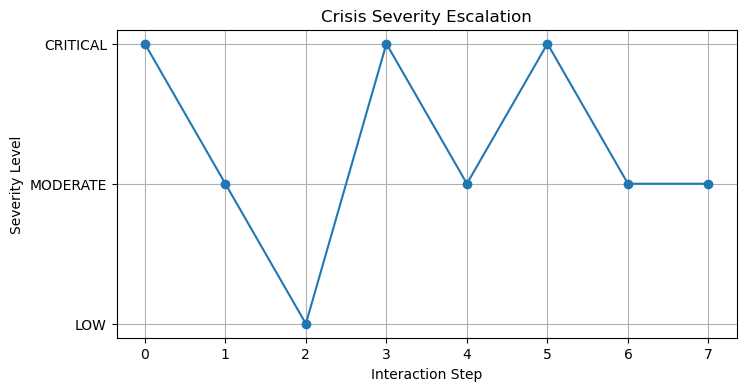

In [29]:
plot_severity_timeline()

In [39]:
await generate_summary()

'**Crisis Summary:**\n\n*   **Crisis Type:** The interaction involved a dual crisis: a potential fire emergency (smelling smoke, feeling dizzy) and a personal threat (being followed).\n*   **Severity Progression:** The initial report of smoke and dizziness was flagged as **CRITICAL**, indicating an immediate life-threatening situation. The subsequent report of being followed was assessed as **MODERATE** severity.\n*   **Agents Involved:**\n    *   **FireAgent:** Responded to the critical fire-related symptoms.\n    *   **ThreatAgent:** Responded to the moderate threat situation.\n*   **Recommended Next Actions:**\n    *   **For the fire/dizziness:** The user was repeatedly instructed by FireAgent to evacuate immediately, stay low, check doors for heat, and use stairs.\n    *   **For the threat:** The user was prompted by ThreatAgent to assess immediate danger and move to a public, well-lit area.\n\n**Overall Assessment:** The user experienced a rapidly evolving situation with potential

In [27]:
print("Perfect run we've achieved")

Perfect run we've achieved


In [ ]:
# -----------------------------------------
# New New Cell 28, Old cell 42 — Location Setup & Emergency Mapping
# -----------------------------------------

import json

# Emergency numbers by country (expand later if needed)
EMERGENCY_NUMBERS = {
    "india": {"police": "112", "medical": "102", "fire": "101"},
    "usa": {"general": "911"},
    "uk": {"general": "999"},
    "australia": {"general": "000"},
}

user_location = None
emergency_profile = None

def configure_location():
    global user_location, emergency_profile

    print("\n🌍 Before we continue, where are you located?")
    print("(Example: India, USA, UK, Australia)\n")

    loc = input("Your location: ").strip().lower()

    if loc in EMERGENCY_NUMBERS:
        user_location = loc
        emergency_profile = EMERGENCY_NUMBERS[loc]
        print(f"\n📍 Location set to: {loc.upper()}")

        # Friendly confirmation message
        if "general" in emergency_profile:
            print(f"📞 Emergency Number: {emergency_profile['general']}")
        else:
            print(f"🔥 Fire: {emergency_profile.get('fire', 'N/A')}")
            print(f"🚑 Medical: {emergency_profile.get('medical', 'N/A')}")
            print(f"🚓 Police: {emergency_profile.get('police', 'N/A')}")

        print("\n✅ Emergency profile configured.\n")
    else:
        print("\n⚠️ Unknown location — fallback emergency number: 112\n")
        user_location = loc
        emergency_profile = {"general": "112"}

    return emergency_profile


# Run setup once
# configure_location()


